# lab2: Анализ тональности отзывов

---

## Чеклист для сдачи

### Уровень 1 (до 7 баллов)

- [x] Данные подготовлены (TF-IDF + train/test)
- [x] Модель на keras построена и обучена
- [x] Метрики: F1, Precision, Recall
- [x] Графики loss/accuracy по эпохам
- [x] Текстовое объяснение (что делает каждый слой, что такое loss, fit, predict)

### Уровень 2 (до 10 баллов)

Всё из уровня 1 **плюс любые 3 из**:

- [x] Dropout + Early Stopping (+ объяснение)
- [x] Мультиклассовая классификация (softmax, 3 класса)
- [x] Сравнение 2–3 архитектур (таблица метрик + вывод)
- [ ] Forward pass на numpy (совпадение с predict)
- [x] Embedding вместо TF-IDF

---

##### Полная версия датасета - https://www.kaggle.com/datasets/mar1mba/russian-sentiment-dataset?select=sentiment_dataset.csv

---

## Инициализация

In [86]:
import numpy as np
import os
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras import layers, models, callbacks, Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [44]:
# funcs init
if os.path.exists('data/sentiment_dataset.csv'):
    data_path = 'data/sentiment_dataset.csv'         # Полная версия датасета
    test_data = False                                # True/False, чтобы выполнить срез данных или нет.
    is_small_data = False
else:
    data_path = 'data/sentiment_test_10k.csv'        # demo версия датасета
    test_data = True                                 # По умолчанию рекомендуется использовать True
    is_small_data = True


vectorizer = TfidfVectorizer(max_features=15000)


## Data upload

In [45]:
# Загрузка + перемешивание
df = pd.read_csv(data_path).sample(frac=1, random_state=42).reset_index(drop=True)
if test_data:
    df = df[:45000]
df

,text,label,src
0,Наблюдал веселую картину: сотрудник сто чуть н...,2,geo
1,"После просмотра данного анимэ, странное чувств...",0,anime
2,платье велико !\n\n\n\n\n\nВиталий.\n\ne-mail:...,0,ru-reviews-classification
3,"качество отвратительное, колючая. нет ни перед...",0,rureviews
4,Достоинства: Густая и очень вкусная Моя любима...,1,perekrestok
...,...,...,...
44995,"Раньше покупала, были хорошего качества. Сейч...",2,perekrestok
44996,"Вкусные, не раскрошенные. Не соленые.",1,perekrestok
44997,"Фильм очень прямолинейный, сделан как комикс -...",2,kinopoisk
44998,"Одни кости и жилы, мяса по минимуму",2,perekrestok


## Preprocessing

In [46]:
# Векторизация + разделение 80/20 + stratify
X = vectorizer.fit_transform(df["text"]).toarray()
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [47]:
# Считаем токены по пробелам
# lengths = X_train.str.split().str.len()
# print(f"Min: {lengths.min()}, Avg: {lengths.mean():.1f}, Max: {lengths.max()}, 95%: {lengths.quantile(0.95):.1f}")

# output: Min: 0, Avg: 51.2, Max: 279, 95%: 180.0

## Baseline model

In [48]:
# ---------- Параметры ----------
input_dim = 15000  # Наш MAX_features
num_classes = 3    # 0: neutral, 1: positive, 2: negative

# ---------- Слои ----------
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),     # Скрытый пул, ой, слой (нейроны учат признаки)
    layers.Dense(num_classes, activation='softmax')                           # output: вероятности для 3 классов = 1.0
])

# Компиляция
# sparse_categorical_crossentropy необходим для мультикласса. 3+ классов.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------- Обучение ----------
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=1,
)

print("Модель обучена!")

model.summary()

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.6368 - loss: 0.8070 - val_accuracy: 0.6711 - val_loss: 0.7156
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.7728 - loss: 0.5485 - val_accuracy: 0.6567 - val_loss: 0.7605
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.8306 - loss: 0.4289 - val_accuracy: 0.6413 - val_loss: 0.8482
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.8723 - loss: 0.3387 - val_accuracy: 0.6338 - val_loss: 0.9733
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9048 - loss: 0.2659 - val_accuracy: 0.6296 - val_loss: 1.1176
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9295 - loss: 0.2068 - val_accuracy: 0.6249 - val_loss: 1.2694
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9475 - loss: 0.1605 - val_accuracy: 0.6194 - val_loss: 1.4192
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9610 - loss: 0.1241 - va

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,761,547 (21.98 MB)

 Trainable params: 1,920,515 (7.33 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,841,032 (14.65 MB)

## Visuals + metrics

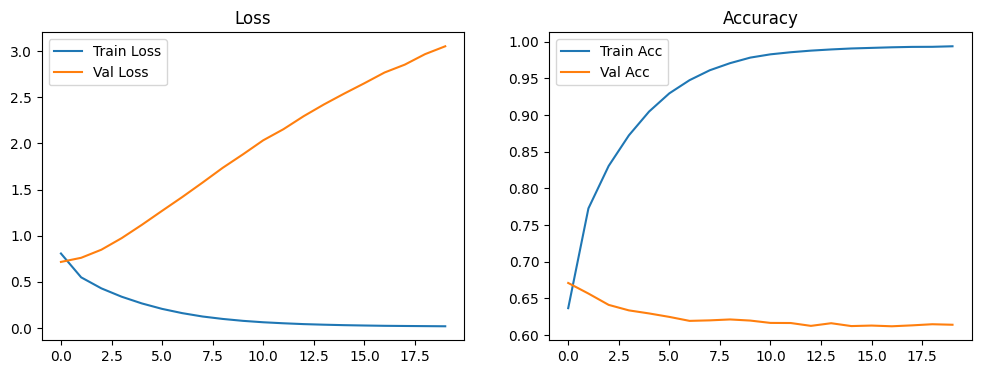

In [52]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [56]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

     Neutral       0.51      0.49      0.50      3019
    Positive       0.72      0.70      0.71      3003
    Negative       0.59      0.63      0.61      2978

    accuracy                           0.61      9000
   macro avg       0.61      0.61      0.61      9000
weighted avg       0.61      0.61      0.61      9000



#### По итогам всех построений и настройки модели - можно сделать выводы, что модель ушла в overfitting.
> - Графики показывают явный разрыв между тренировочной и валидационной выборкой.
>
> - Метрики оставляют желать лучшего
>
> - Модель очень плохо различает класс Neutral

#### Касательно мультиклассовой задачи, в датасете изначально предусмотрена мультиклассовость, поэтому принято решение не строить бинарку
> Немного о разнице в softmax и sigmoid
>
> - sigmoid превращает вывод из последнего слоя модели в значение от 0 до 1, которое можно считать за вероятность (Да/Нет)
>
> - softmax позволяет как раз таки работать с мультиклассовостью, он получает вывод из последнего слоя в виде нескольких чисел и делит на количество входящих ранее значений. Возвращается список вида [0.2, 0.6, 0.2], как вероятности относительно 3 классов.

#### loss, задачи слоёв, fit/predict
> loss штрафует модель за неверные предикты, чем чаще ошибается - тем выше штраф, некий кнут
>
> Есть несколько видов слоёв
> > - Слой входа (Input) - явно указывает слой входа, вместо того, чтобы вписывать его в Dense (необязательный)
> > - Слой полносвязный (Dense) - основной слой, который отвечает за поиск зависимостей, поиск слов которые отвечают за тот или иной класс
> > - Есть ещё параметры активации: ReLU, sigmoid и softmax. ReLU обнуляет значения, про остальные чуть выше в этом блоке.


## Improvements for models

#### Dropout-слой + EarlyStopping

In [70]:
# ---------- Параметры ----------

num_classes = 3    # 0: neutral, 1: positive, 2: negative

# ---------- Слои ----------
model_2 = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# ---------- Компиляция ----------
# sparse_categorical_crossentropy необходим для мультикласса. 3+ классов.

model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------- EarlyStopping ----------

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ---------- Обучение ----------
history2 = model_2.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=early_stop,
    verbose=1,
)

print("Модель обучена!")

model_2.summary()

Epoch 1/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6257 - loss: 0.8543 - val_accuracy: 0.6682 - val_loss: 0.7287
Epoch 2/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7482 - loss: 0.6039 - val_accuracy: 0.6646 - val_loss: 0.7251
Epoch 3/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8034 - loss: 0.4924 - val_accuracy: 0.6551 - val_loss: 0.7638
Epoch 4/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8415 - loss: 0.4136 - val_accuracy: 0.6457 - val_loss: 0.8225
Epoch 5/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8707 - loss: 0.3500 - val_accuracy: 0.6381 - val_loss: 0.8985
Модель обучена!


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │       960,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,880,779 (10.99 MB)

 Trainable params: 960,259 (3.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,920,520 (7.33 MB)

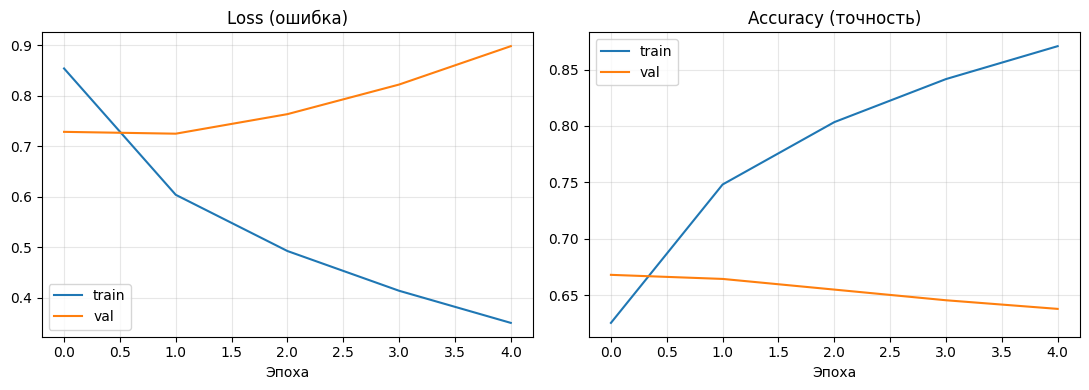

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history2.history["loss"], label="train")
axes[0].plot(history2.history["val_loss"], label="val")
axes[0].set_title("Loss (ошибка)")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history2.history["accuracy"], label="train")
axes[1].plot(history2.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy (точность)")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
y_pred = np.argmax(model_2.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

     Neutral       0.56      0.61      0.58      3019
    Positive       0.80      0.74      0.77      3003
    Negative       0.68      0.66      0.67      2978

    accuracy                           0.67      9000
   macro avg       0.68      0.67      0.68      9000
weighted avg       0.68      0.67      0.68      9000



Как итог, метрики немного изменились в лучшую сторону, с такой положительной динамикой можно двигаться дальше

> - **Dropout** помог нам сократить число нейронов, что "заставило" другие нейроны работать.
>
> - Помогает избежать оверфита модели, ведь если будет условно "авторитетный" эксперт, то его выводы вместе с шумом будут выдавать неверные результаты.

> - **EarlyStopping** помогает просто закончить обучение модели, если метрики перестают меняться (оптимизация)

#### Сравнение архитектур с разным количеством слоёв

In [82]:
# Конфигурации: [нейроны в слоях]. Последний '3' - это выходной слой под 3 класса
configs = {
    "Tiny (16)":       [16, 3],
    "Wide (128)":       [128, 3],
    "Medium (32→16)":  [32, 16, 3],
    "Deep (64→32→16)": [64, 32, 16, 3],
}

results = []

for name, sizes in configs.items():
    model = Sequential()

    model.add(layers.Input(shape=(X_train.shape[1],)))  # Явный вход - минус WARNING
    model.add(layers.Dense(sizes[0], activation='relu'))

    for s in sizes[1:-1]:
        model.add(layers.Dense(s, activation='relu'))

    # Выходной слой: 3 нейрона + softmax для вероятностей классов
    model.add(layers.Dense(sizes[-1], activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    model.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=32,
        verbose=0
    )

    y_pred_classes = model.predict(X_test, verbose=0).argmax(axis=1)
    y_true_classes = y_train if False else (y_test.values if hasattr(y_test, 'values') else y_test)

    results.append({
        "Архитектура": name,
        "F1 (macro)": round(f1_score(y_true_classes, y_pred_classes, average='macro'), 4),
        "Precision": round(precision_score(y_true_classes, y_pred_classes, average='macro'), 4),
        "Recall": round(recall_score(y_true_classes, y_pred_classes, average='macro'), 4)
    })

pd.DataFrame(results).sort_values(by="F1 (macro)", ascending=False)

,Архитектура,F1 (macro),Precision,Recall
3,Deep (64→32→16),0.6315,0.6319,0.6317
1,Wide (128),0.6205,0.6205,0.6207
2,Medium (32→16),0.6135,0.6129,0.6142
0,Tiny (16),0.6094,0.6102,0.6087


##### По итогу мы видим таблицу с метриками. Для интереса была добавлена модель с одним широким слоем в 128 нейронов.

> По показателям лидирует конечно **глубина**, однако важно правильно подобраться размер первого слоя относительно входных данных.
>
> Можно сделать выводы, что **широкая модель** показала себя практически также хорошо, как и **глубокая**, скорее всего это связано с правильно подобранными параметрами слоёв.
>
> Так что да, огромная размерность одного слоя может быть неэффективна и привести к **оверфиту**, поэтому важно сочетать два основных параметра **глубины** и **ширины**

## Embendding + Dropout + ES + multiclassification = ?

In [111]:
# ==========================================
#                  CONFIG
# ==========================================

if is_small_data:
    is_test_sample = is_small_data
else:
    is_test_sample = False          # True (45k) или False (290k+)

if is_test_sample:
    print("ТЕСТОВЫЙ объём")
    max_samples = 45000 # Срез из max_samples
    vocab_size = 12000
    embedding_dim = 50
    batch_size = 32

else:
    print("Полный датасет")
    max_samples = None  # Берем все данные
    vocab_size = 30000
    embedding_dim = 64
    batch_size = 128

epochs = 20
max_len = 180

Полный датасет


In [112]:
# ==========================================
#         DATA UPLOAD & PROCESSING
# ==========================================

df = pd.read_csv(data_path).sample(frac=1, random_state=42).reset_index(drop=True)

if max_samples:
    df = df[:max_samples]

print(f"Размер выборки: {len(df)} записей.")

X_text = df['text'].astype(str).values
y_labels = df['label'].values

# Токенизация текста
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_text)

X_seq = tokenizer.texts_to_sequences(X_text)
X_emb = pad_sequences(X_seq, maxlen=max_len)

X_train, X_test, y_train, y_test = train_test_split(
    X_emb, y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Размер выборки: 290458 записей.
Train: (232366, 180), Test: (58092, 180)


In [116]:
# ==========================================
#        MODEL (Embedding + Pooling)
# ==========================================
model = Sequential([
    layers.Input(shape=(max_len,)),
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    layers.GlobalAveragePooling1D(), # Сжатие векторов в 1 для скрытого пула

    layers.Dense(64 if is_test_sample else 128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(32 if is_test_sample else 64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')     # 3 класса (Multiclass)
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # Работает с целочисленными метками
    metrics=['accuracy']
)

model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 180, 64)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_71 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,936,771 (7.39 MB)

 Trainable params: 1,936,771 (7.39 MB)

 Non-trainable params: 0 (0.00 B)

In [117]:
# ==========================================
#                  FITTING
# ==========================================
early_stop_emb = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=early_stop_emb,
    verbose=1
)

Epoch 1/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.5508 - loss: 0.8920 - val_accuracy: 0.5666 - val_loss: 0.8548
Epoch 2/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.6514 - loss: 0.7439 - val_accuracy: 0.6773 - val_loss: 0.6975
Epoch 3/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.6856 - loss: 0.6900 - val_accuracy: 0.6601 - val_loss: 0.7220
Epoch 4/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.7016 - loss: 0.6617 - val_accuracy: 0.6982 - val_loss: 0.6846
Epoch 5/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7167 - loss: 0.6340 - val_accuracy: 0.7082 - val_loss: 0.6639
Epoch 6/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7260 - loss: 0.6154 - val_accuracy: 0.7076 - val_loss: 0.6801
Epoch 7/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.7374 - loss: 0.5940 - val_accuracy: 0.6544 - val_loss: 0.7865
Epoch 8/20
1634/1634 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.7458 -

In [118]:
# ==========================================
#                  METRICS
# ==========================================
y_pred_probs = model.predict(X_test, verbose=0)
y_pred_classes = y_pred_probs.argmax(axis=1)

print("\n=============== classification report ===============")
print(classification_report(y_test, y_pred_classes, target_names = ['Neutral', 'Positive', 'Negative']))

f1_macro = f1_score(y_test, y_pred_classes, average='macro')
print(f"🏆 F1-Score (Macro): {f1_macro:.4f}")


=============== classification report ===============
              precision    recall  f1-score   support

     Neutral       0.58      0.64      0.61     19318
    Positive       0.82      0.79      0.80     19375
    Negative       0.73      0.68      0.70     19399

    accuracy                           0.70     58092
   macro avg       0.71      0.70      0.71     58092
weighted avg       0.71      0.70      0.71     58092

🏆 F1-Score (Macro): 0.7052


### Итоги финального улучшения модели

Во время тестов с гиперпараметрами и объёмом выборки был сделан вывод, что наилучшие результаты достигаются на полной выборке. Модель начинает лучше распознавать нейтральные отзывы
> как следствие - растут метрики других классов

По наблюдениям, глубина и ширина слоёв очень сильно коррелирует с размером входящих данных.

Да и в целом, от таких размеров выборки научиться давно пора)

#### Отличия Embedding от TF-IDF

> - У Embedding меньше объёмы признаков (мы сжимаем вектор), поскольку они настраиваются вручную. TF-IDF самостоятельно создаёт признаки и занимает много памяти - разряжённый вектор (на тестах я лишился 70% оперативы, а она дорогая нынче)
>
> - Семантическая зависимость есть только у Embedding, TF-IDF не учитывает смысл слов
>
> - Embedding раскрывается только на больших объёмах данных

Изначальный датасет сам по себе не самый лучший вариант, потому что там разные источники текстов, что в семантике конкретных предприятий неэффективно.

Например, если DNS решит построить модель для определения тональности отзывов, то гораздо эффективнее будет использовать выборку отзывов внутри сети DNS, а не с WB, просто разный контекст может сбивать модель при определении тональности.